# Workplace Safety Risk Detection — EDA Notebook

This notebook performs exploratory data analysis for the OSHA workplace safety risk project.

Goal: understand establishment-level safety patterns before modeling.

We will examine:
- Data structure and quality
- Injury/illness distributions
- Establishment size and industry patterns
- Total Recordable Incident Rate (TRIR)
- High-risk threshold options
- Case-detail injury/event patterns
- Merge feasibility between summary and case-detail data

In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

SUMMARY_ZIP = Path("ITA_300A_Summary_Data_2024_through_12-31-2025.zip")
CASE_ZIP = Path("ITA_Case_Detail_Data_2024_through_12-31-2025.zip")


## 1. Load the OSHA ZIP Files


In [2]:
def read_single_csv_zip(zip_path, encoding="latin1"):
    """Read the first CSV inside a ZIP file."""
    if not zip_path.exists():
        raise FileNotFoundError(f"Could not find: {zip_path}. Put the ZIP in this notebook folder or update the path.")
    with zipfile.ZipFile(zip_path) as z:
        csv_files = [name for name in z.namelist() if name.lower().endswith(".csv")]
        if not csv_files:
            raise ValueError(f"No CSV file found inside {zip_path}")
        csv_name = csv_files[0]
        print(f"Reading {csv_name} from {zip_path.name}...")
        with z.open(csv_name) as f:
            return pd.read_csv(f, encoding=encoding, low_memory=False)

summary_df = read_single_csv_zip(SUMMARY_ZIP)
case_df = read_single_csv_zip(CASE_ZIP)

print("Summary shape:", summary_df.shape)
print("Case-detail shape:", case_df.shape)

Reading ITA_300A_Summary_Data_2024_through_12-31-2025.csv from ITA_300A_Summary_Data_2024_through_12-31-2025.zip...
Reading ITA_Case_Detail_Data_2024_through_12-31-2025.csv from ITA_Case_Detail_Data_2024_through_12-31-2025.zip...
Summary shape: (398620, 32)
Case-detail shape: (688649, 49)


## 2. Initial Structure Check

In [3]:
display(summary_df.head())
display(case_df.head())

,id,establishment_name,establishment_id,ein,company_name,street_address,city,state,zip_code,naics_code,naics_year,industry_description,establishment_type,size,annual_average_employees,total_hours_worked,no_injuries_illnesses,total_deaths,total_dafw_cases,total_djtr_cases,total_other_cases,total_dafw_days,total_djtr_days,total_injuries,total_skin_disorders,total_respiratory_conditions,total_poisonings,total_hearing_loss,total_other_illnesses,created_timestamp,change_reason,year_filing_for
0,2808362,AristaCare at Meadow Springs,41940,204755042.0,AristaCare at Meadow Springs LLC,845 Germantown Pike,Plymouth Meeting,PA,19462,623110,2012,Skilled nursing facilities,1.0,3,315,389754,1,0,1,5,1,1,32,7,0,0,0,0,0,28FEB25:16:35:00,NaN,2024
1,2587120,AM Braswell Jr. Food Company,41942,580667528.0,AM Braswell Jr. Food Company,226 North Zetterower Avenue,Statesboro,GA,30458,311421,2012,Canning jams and jellies,1.0,22,119,98259,1,0,7,4,0,46,69,10,0,0,0,0,1,31JAN25:20:24:00,NaN,2024
2,2575264,"SMM Group Chesapeake, VA",41952,453807558.0,Sims Metal Management,4300 Buell Street,Chesapeake,VA,23324,423930,2012,Metal scrap and waste merchant wholesalers,1.0,22,126,278678,1,0,0,0,1,0,0,1,0,0,0,0,0,29JAN25:14:47:00,NaN,2024
3,2575218,"SMM Group Richmond, VA",41955,453807558.0,Sims Metal Management,3220 Deepwater Terminal Road,Richmond,VA,23234,423930,2012,Metal scrap and waste merchant wholesalers,1.0,21,35,68943,2,0,0,0,0,0,0,0,0,0,0,0,0,29JAN25:14:31:00,NaN,2024
4,2505064,FRP Sheet Metal Contracting Corp,41983,112459740.0,FRP Sheet Metal Contracting Corp,365 Wyandanch Ave.,West Babylon,NY,11704,238220,2012,Air-conditioning system (except window) instal...,1.0,21,25,40919,2,0,0,0,0,0,0,0,0,0,0,0,0,07JAN25:20:06:00,NaN,2024


,id,establishment_id,establishment_name,ein,company_name,street_address,city,state,zip_code,naics_code,naics_year,industry_description,establishment_type,size,annual_average_employees,total_hours_worked,case_number,job_description,soc_code,soc_description,soc_reviewed,soc_probability,date_of_incident,incident_outcome,dafw_num_away,djtr_num_tr,type_of_incident,time_started_work,time_of_incident,time_unknown,date_of_death,created_timestamp,year_of_filing,NEW_NAR_WHAT_HAPPENED,NEW_NAR_BEFORE_INCIDENT,NEW_INCIDENT_LOCATION,NEW_NAR_INJURY_ILLNESS,NEW_NAR_OBJECT_SUBSTANCE,NEW_INCIDENT_DESCRIPTION,nature_code_pred,nature_title_pred,part_code_pred,part_title_pred,event_code_pred,event_title_pred,source_code_pred,source_title_pred,sec_source_code_pred,sec_source_title_pred
0,936394,1147869,\tCEVA Logistics Airtech 1680201H\t\t\t\t\t\t\...,232142673.0,"CEVA Contract Logistics US, Inc.",\t501 Airtech Parkway\t\t\t\t\t\t\t\t\t\t\t\t\...,Plainfield,IN,46168,493110,2022,"Bonded warehousing, general merchandise",1.0,3,337,834292,1,Warehouse Associate,53-7065,Stockers and Order Fillers,1,5.000000,16JAN2024,4,0,0,1,7:00,13:30,0.0,NaN,20JAN2025:16:52:00,2024,While cutting towards self lacerated left inde...,Opening packages using a retractable knife,Production,Laceration to left index finger,Retractable knife,Left index finger laceration from retractable ...,13.0,Surface and flesh wounds,44.0,"Hand(s), finger(s)",66.0,Contact with non-running objects or equipment,71.0,Handtools,99.0,"Other source, secondary source"
1,936437,1147869,\tCEVA Logistics Airtech 1680201H\t\t\t\t\t\t\...,232142673.0,"CEVA Contract Logistics US, Inc.",\t501 Airtech Parkway\t\t\t\t\t\t\t\t\t\t\t\t\...,Plainfield,IN,46168,493110,2022,"Bonded warehousing, general merchandise",1.0,3,337,834292,2,Warehouse Associate,53-7065,Stockers and Order Fillers,1,5.000000,17APR2024,2,1,51,1,7:00,7:30,0.0,NaN,20JAN2025:16:58:00,2024,Associate stepped backwards and tripped over a...,Scanning items on pallet,Production,Acral pain and contusion of sacrum,Wood pallet and concrete floor,acral pain Contusion of sacrum tripping over a...,13.0,Surface and flesh wounds,32.0,Exterior and musculoskeletal structures of the...,43.0,"Slip, trip, stumble or fall on same level",66.0,"Ground, travel, and support surfaces",21.0,Containers
2,936469,1147869,\tCEVA Logistics Airtech 1680201H\t\t\t\t\t\t\...,232142673.0,"CEVA Contract Logistics US, Inc.",\t501 Airtech Parkway\t\t\t\t\t\t\t\t\t\t\t\t\...,Plainfield,IN,46168,493110,2022,"Bonded warehousing, general merchandise",1.0,3,337,834292,3,Warehouse Associate,53-7065,Stockers and Order Fillers,1,5.000000,07MAY2024,3,0,27,1,7:00,9:08,0.0,NaN,20JAN2025:17:08:00,2024,Grabbed a tote with one hand bending back left...,Scanning items for put away,Production,Left wrist and hand strain,Tote,Strain of left hand and wrist after grabbing a...,14.0,Soft tissue injuries,48.0,Multiple upper extremities locations,71.0,Overexertion while moving or manipulating exte...,21.0,Containers,99.0,"Other source, secondary source"
3,1373294,801065,"\tSeah Steel USA LLC, P1\t\t\t\t\t\t\t\t\t\t\t",384017653.0,Seah Steel USA,16952 Leonard Rd.,Houston,TX,77049,331210,2012,"Pipe (e.g., heavy riveted, lock joint, seamles...",1.0,22,123,415164,1,Gag operator,51-4031,"Cutting, Punching, and Press Machine Setters, ...",0,0.999987,24AUG2024,3,0,14,1,19:00,22:50,0.0,NaN,27FEB2025:19:09:00,2024,Employee was placing a stopper on pipe and nex...,Counting Pipe and Marking,Gag Table,Right Hand Injury,Pipe,Smashed Finger,10.0,Traumatic injuries or exposures-- nonspecific ...,44.0,"Hand(s), finger(s)",66.0,Contact with non-running objects or equipment,42.0,Building materials,99.0,"Other source, secondary source"
4,1374268,801065,"\tSeah Steel USA LLC, P1\t\t\t\t\t\t\t\t\t\t\t",384017653.0,Seah Steel USA,16952 Leonard Rd.,Houston,TX,77049,331210,2012,"Pipe (e.g., heavy riveted, lock joint, seamles...",1.0,22,123,415164,2,QA operator,51-2041,Structural Metal Fabricators and Fitters,0,0.935129,15NO

In [4]:
print("Summary columns:")
print(summary_df.columns.tolist())

print("\nCase-detail columns:")
print(case_df.columns.tolist())

Summary columns:
['id', 'establishment_name', 'establishment_id', 'ein', 'company_name', 'street_address', 'city', 'state', 'zip_code', 'naics_code', 'naics_year', 'industry_description', 'establishment_type', 'size', 'annual_average_employees', 'total_hours_worked', 'no_injuries_illnesses', 'total_deaths', 'total_dafw_cases', 'total_djtr_cases', 'total_other_cases', 'total_dafw_days', 'total_djtr_days', 'total_injuries', 'total_skin_disorders', 'total_respiratory_conditions', 'total_poisonings', 'total_hearing_loss', 'total_other_illnesses', 'created_timestamp', 'change_reason', 'year_filing_for']

Case-detail columns:
['id', 'establishment_id', 'establishment_name', 'ein', 'company_name', 'street_address', 'city', 'state', 'zip_code', 'naics_code', 'naics_year', 'industry_description', 'establishment_type', 'size', 'annual_average_employees', 'total_hours_worked', 'case_number', 'job_description', 'soc_code', 'soc_description', 'soc_reviewed', 'soc_probability', 'date_of_incident', '

In [5]:
summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398620 entries, 0 to 398619
Data columns (total 32 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            398620 non-null  int64  
 1   establishment_name            398620 non-null  object 
 2   establishment_id              398620 non-null  int64  
 3   ein                           355360 non-null  float64
 4   company_name                  379082 non-null  object 
 5   street_address                398618 non-null  object 
 6   city                          398618 non-null  object 
 7   state                         398620 non-null  object 
 8   zip_code                      398620 non-null  int64  
 9   naics_code                    398620 non-null  int64  
 10  naics_year                    398620 non-null  int64  
 11  industry_description          371824 non-null  object 
 12  establishment_type            398065 non-nul

In [6]:
case_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688649 entries, 0 to 688648
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        688649 non-null  int64  
 1   establishment_id          688649 non-null  int64  
 2   establishment_name        688649 non-null  object 
 3   ein                       628314 non-null  float64
 4   company_name              652272 non-null  object 
 5   street_address            688649 non-null  object 
 6   city                      688649 non-null  object 
 7   state                     688649 non-null  object 
 8   zip_code                  688649 non-null  int64  
 9   naics_code                688649 non-null  int64  
 10  naics_year                688649 non-null  int64  
 11  industry_description      636451 non-null  object 
 12  establishment_type        687625 non-null  float64
 13  size                      688649 non-null  i

## 3. Basic Cleaning for EDA

This cleaning is intentionally conservative. The goal is to make categories readable and numeric fields usable for EDA, not to create final modeling features yet.

In [7]:
def clean_text_columns(df):
    df = df.copy()
    object_cols = df.select_dtypes(include="object").columns
    for col in object_cols:
        df[col] = (df[col]
                   .astype("string")
                   .str.replace("\t", " ", regex=False)
                   .str.replace(r"\s+", " ", regex=True)
                   .str.strip())
        df[col] = df[col].replace({"": pd.NA, "nan": pd.NA, "NaN": pd.NA})
    return df

summary_clean = clean_text_columns(summary_df)
case_clean = clean_text_columns(case_df)

# Convert selected numeric fields safely
summary_numeric_cols = [
    "establishment_id", "naics_code", "annual_average_employees", "total_hours_worked",
    "total_deaths", "total_dafw_cases", "total_djtr_cases", "total_other_cases",
    "total_dafw_days", "total_djtr_days", "total_injuries", "year_filing_for"
]
case_numeric_cols = [
    "establishment_id", "naics_code", "annual_average_employees", "total_hours_worked",
    "case_number", "incident_outcome", "dafw_num_away", "djtr_num_tr",
    "type_of_incident", "year_of_filing", "nature_code_pred", "part_code_pred",
    "event_code_pred", "source_code_pred"
]

for col in summary_numeric_cols:
    if col in summary_clean.columns:
        summary_clean[col] = pd.to_numeric(summary_clean[col], errors="coerce")

for col in case_numeric_cols:
    if col in case_clean.columns:
        case_clean[col] = pd.to_numeric(case_clean[col], errors="coerce")


## 4. Data Quality Checks

In [8]:
def missing_report(df, name, top_n=25):
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "dtype": df.dtypes.astype(str)
    }).sort_values("missing_pct", ascending=False)
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
    return report.head(top_n)

display(missing_report(summary_clean, "Summary data"))
display(missing_report(case_clean, "Case-detail data"))

Summary data: 398,620 rows x 32 columns


,missing_count,missing_pct,dtype
change_reason,384744,96.518991,string
ein,43260,10.852441,float64
industry_description,26796,6.722192,string
company_name,19538,4.901410,string
establishment_type,555,0.139230,float64
street_address,2,0.000502,string
city,2,0.000502,string
establishment_id,0,0.000000,int64
state,0,0.000000,string
id,0,0.000000,int64


Case-detail data: 688,649 rows x 49 columns


,missing_count,missing_pct,dtype
date_of_death,688649,100.000000,float64
case_number,241912,35.128491,Float64
part_title_pred,206055,29.921629,string
part_code_pred,206055,29.921629,float64
time_started_work,75873,11.017659,string
time_of_incident,65495,9.510651,string
ein,60335,8.761357,float64
industry_description,52198,7.579769,string
event_title_pred,40206,5.838388,string
event_code_pred,40206,5.838388,float64


In [9]:
print("Summary duplicate rows:", summary_clean.duplicated().sum())
print("Case-detail duplicate rows:", case_clean.duplicated().sum())

print("\nUnique summary establishments:", summary_clean["establishment_id"].nunique())
print("Unique case-detail establishments:", case_clean["establishment_id"].nunique())

Summary duplicate rows: 0
Case-detail duplicate rows: 0

Unique summary establishments: 398620
Unique case-detail establishments: 64674


## 5. Establishment Summary EDA

The 300A summary data is the main establishment-level table. This section explores injuries, hours worked, employment size, geography, and industry.

In [10]:
summary_clean[[
    "annual_average_employees", "total_hours_worked", "total_deaths",
    "total_dafw_cases", "total_djtr_cases", "total_other_cases",
    "total_dafw_days", "total_djtr_days", "total_injuries"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
annual_average_employees,398620.0,3.482868e+02,7.141828e+04,0.0,20.0,42.0,103.00,4.109260e+07
total_hours_worked,398620.0,2.671577e+06,1.367912e+09,0.0,24804.0,68190.5,176297.75,8.628470e+11
total_deaths,398620.0,2.037028e-03,5.138073e-02,0.0,0.0,0.0,0.00,1.100000e+01
total_dafw_cases,398620.0,1.317024e+00,7.238057e+00,0.0,0.0,0.0,1.00,1.113000e+03
total_djtr_cases,398620.0,1.078666e+00,6.740041e+00,0.0,0.0,0.0,1.00,1.947000e+03
total_other_cases,398620.0,1.348166e+00,8.515012e+00,0.0,0.0,0.0,1.00,2.159000e+03
total_dafw_days,398620.0,1.871074e+02,8.799355e+04,0.0,0.0,0.0,11.00,5.555556e+07
total_djtr_days,398620.0,5.940978e+01,1.036462e+03,0.0,0.0,0.0,19.00,4.731070e+05
total_injuries,398620.0,3.461334e+00,1.591404e+01,0.0,0.0,1.0,3.00,2.411000e+03


### Create EDA Metric

TRIR (Total Recordable Incident Rate) is calculated as:

TRIR = (total recordable cases x 200,000) / total hours worked

*40 hours worked x 50 weeks per year x 100 employees = 200,000

Total recordable cases are calculated as:

total_dafw_cases + total_djtr_cases + total_other_cases

In [11]:
summary_eda = summary_clean.copy()

summary_eda["total_recordable_cases"] = (
    summary_eda.get("total_dafw_cases", 0).fillna(0)
    + summary_eda.get("total_djtr_cases", 0).fillna(0)
    + summary_eda.get("total_other_cases", 0).fillna(0)
)

summary_eda["trir"] = np.where(
    summary_eda["total_hours_worked"] > 0,
    (summary_eda["total_recordable_cases"] * 200_000) / summary_eda["total_hours_worked"],
    np.nan
)

summary_eda["dafw_case_rate"] = np.where(
    summary_eda["total_hours_worked"] > 0,
    (summary_eda["total_dafw_cases"] * 200_000) / summary_eda["total_hours_worked"],
    np.nan
)

summary_eda["days_away_restricted_total"] = (
    summary_eda.get("total_dafw_days", 0).fillna(0)
    + summary_eda.get("total_djtr_days", 0).fillna(0)
)

summary_eda["avg_days_per_recordable_case"] = np.where(
    summary_eda["total_recordable_cases"] > 0,
    summary_eda["days_away_restricted_total"] / summary_eda["total_recordable_cases"],
    np.nan
)


summary_eda[["total_recordable_cases", "trir", "dafw_case_rate", "avg_days_per_recordable_case"]].describe().T

,count,mean,std,min,25%,50%,75%,max
total_recordable_cases,398620.0,3.743856,18.135154,0.0,0.0,1.000000,3.000000,3054.0
trir,397046.0,13.363222,1135.314255,0.0,0.0,1.617449,5.678269,400000.0
dafw_case_rate,397046.0,5.687047,598.447866,0.0,0.0,0.000000,1.551083,200000.0
avg_days_per_recordable_case,227528.0,151.321315,58234.789647,0.0,2.0,14.375000,39.500000,27777783.5


In [12]:
summary_eda_clean = summary_eda[
    (summary_eda["total_hours_worked"] > 0) &
    (summary_eda["annual_average_employees"] > 0) &
    (summary_eda["trir"].notna())
].copy()

trir_upper = summary_eda_clean["trir"].quantile(0.99)

summary_eda_clean = summary_eda_clean[
    summary_eda_clean["trir"] <= trir_upper
].copy()

summary_eda_clean.shape

(392915, 37)

In [13]:
quality_checks = {
    "zero_hours_worked": (summary_eda["total_hours_worked"] == 0).sum(),
    "zero_employees": (summary_eda["annual_average_employees"] == 0).sum(),
    "missing_trir": summary_eda["trir"].isna().sum()
}

quality_checks

{'zero_hours_worked': np.int64(1574),
 'zero_employees': np.int64(1635),
 'missing_trir': np.int64(1574)}

### Injury and TRIR Distributions

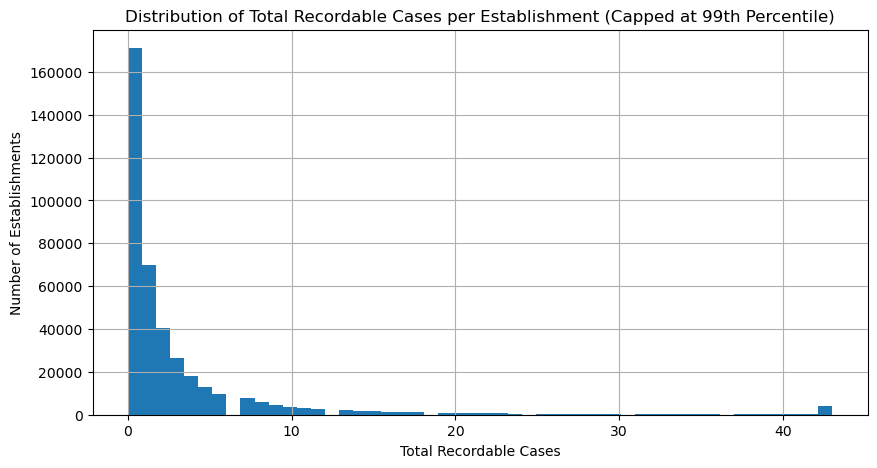

In [14]:
plt.figure(figsize=(10, 5))
summary_eda["total_recordable_cases"].clip(upper=summary_eda["total_recordable_cases"].quantile(0.99)).hist(bins=50)
plt.title("Distribution of Total Recordable Cases per Establishment (Capped at 99th Percentile)")
plt.xlabel("Total Recordable Cases")
plt.ylabel("Number of Establishments")
plt.show()

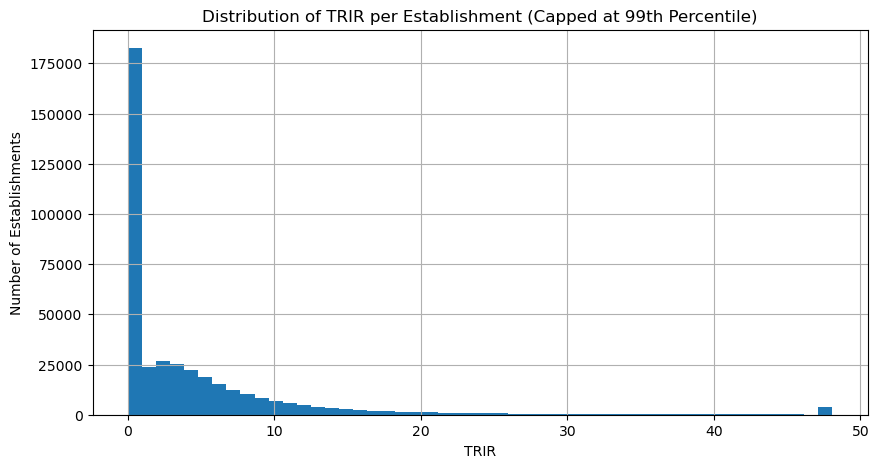

In [15]:
plt.figure(figsize=(10, 5))
summary_eda["trir"].dropna().clip(upper=summary_eda["trir"].quantile(0.99)).hist(bins=50)
plt.title("Distribution of TRIR per Establishment (Capped at 99th Percentile)")
plt.xlabel("TRIR")
plt.ylabel("Number of Establishments")
plt.show()

In [16]:
# Percentiles help choose a defensible high-risk threshold later.
summary_eda[["total_recordable_cases", "trir", "dafw_case_rate", "avg_days_per_recordable_case"]].quantile([0, .25, .50, .75, .90, .95, .99]).T

,0.00,0.25,0.50,0.75,0.90,0.95,0.99
total_recordable_cases,0.0,0.0,1.000000,3.000000,8.000000,14.000000,43.000000
trir,0.0,0.0,1.617449,5.678269,11.426613,17.400275,48.076923
dafw_case_rate,0.0,0.0,0.000000,1.551083,4.798724,8.272325,23.578372
avg_days_per_recordable_case,0.0,2.0,14.375000,39.500000,74.000000,102.000000,180.000000


### Establishment Size and Exposure

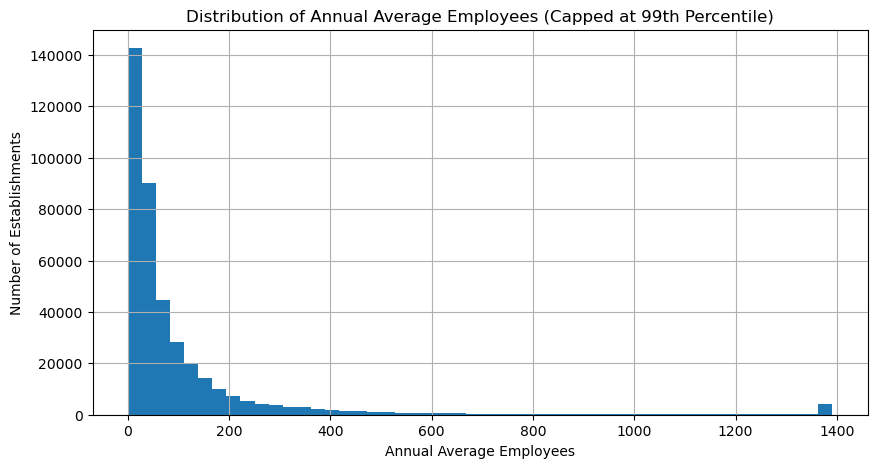

In [17]:
plt.figure(figsize=(10, 5))
summary_eda["annual_average_employees"].dropna().clip(upper=summary_eda["annual_average_employees"].quantile(0.99)).hist(bins=50)
plt.title("Distribution of Annual Average Employees (Capped at 99th Percentile)")
plt.xlabel("Annual Average Employees")
plt.ylabel("Number of Establishments")
plt.show()

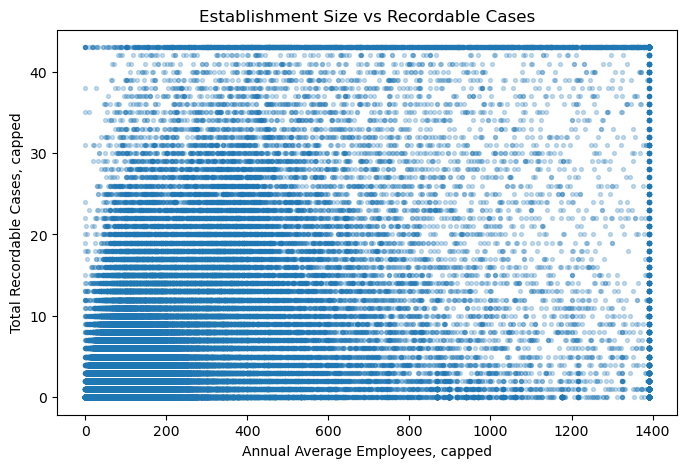

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(
    summary_eda["annual_average_employees"].clip(upper=summary_eda["annual_average_employees"].quantile(0.99)),
    summary_eda["total_recordable_cases"].clip(upper=summary_eda["total_recordable_cases"].quantile(0.99)),
    alpha=0.25,
    s=8
)
plt.title("Establishment Size vs Recordable Cases")
plt.xlabel("Annual Average Employees, capped")
plt.ylabel("Total Recordable Cases, capped")
plt.show()

### State-Level Safety Patterns

In [19]:
state_summary = (summary_eda
    .groupby("state", dropna=False)
    .agg(
        establishments=("establishment_id", "nunique"),
        total_recordable_cases=("total_recordable_cases", "sum"),
        total_hours_worked=("total_hours_worked", "sum"),
        median_trir=("trir", "median"),
        mean_trir=("trir", "mean")
    )
    .reset_index())

state_summary["state_trir"] = np.where(
    state_summary["total_hours_worked"] > 0,
    (state_summary["total_recordable_cases"] * 200_000) / state_summary["total_hours_worked"],
    np.nan
)

state_summary.sort_values("total_recordable_cases", ascending=False).head(15)

,state,establishments,total_recordable_cases,total_hours_worked,median_trir,mean_trir,state_trir
8,CA,40449,201014,23612212660,2.288888,24.884882,1.702627
52,TX,31106,103068,11058986473,0.821818,6.407680,1.863968
13,FL,21656,80994,8998946814,1.550418,9.689114,1.800077
19,IL,16829,72462,15566974946,1.880579,9.074595,0.930971
41,NY,16609,70005,6394549929,1.577992,11.610786,2.189521
45,PA,17030,67305,6358846641,2.284083,11.502306,2.116893
28,MI,13926,53590,19666636195,1.945361,7.175733,0.544984
42,OH,16817,50877,4743394134,1.296781,29.937930,2.145173
57,WA,8816,44084,3015027014,2.969050,10.763350,2.924286
34,NC,14343,43744,3696236653,0.742149,5.515846,2.366948


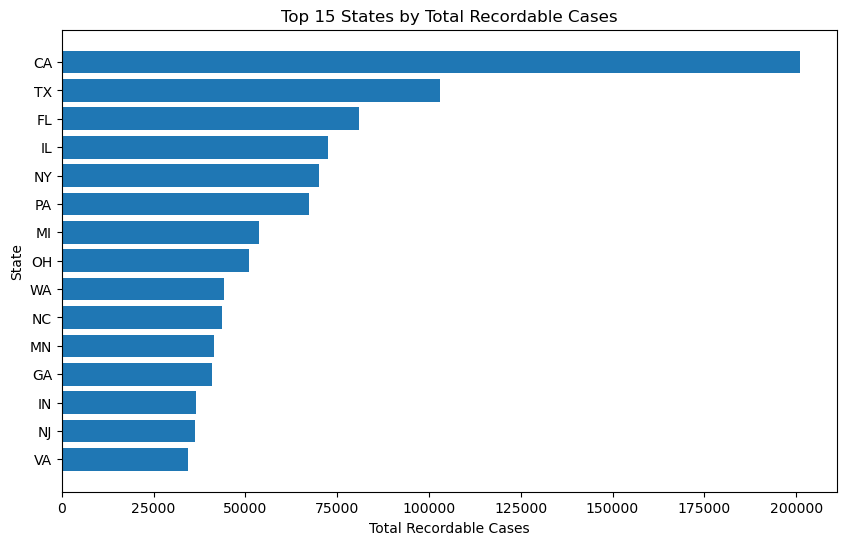

In [20]:
top_states = state_summary.sort_values("total_recordable_cases", ascending=False).head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_states["state"].astype(str), top_states["total_recordable_cases"])
plt.gca().invert_yaxis()
plt.title("Top 15 States by Total Recordable Cases")
plt.xlabel("Total Recordable Cases")
plt.ylabel("State")
plt.show()

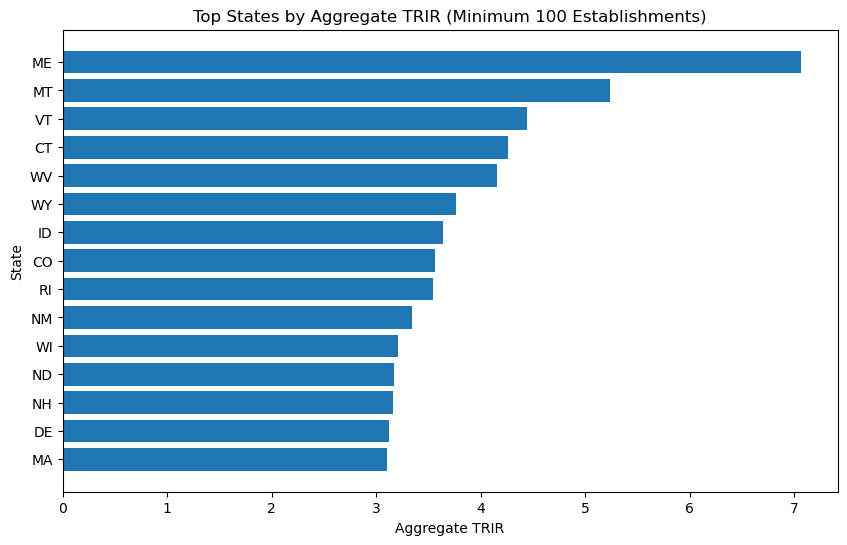

In [21]:
state_rate_view = state_summary[state_summary["establishments"] >= 100].sort_values("state_trir", ascending=False).head(15)
plt.figure(figsize=(10, 6))
plt.barh(state_rate_view["state"].astype(str), state_rate_view["state_trir"])
plt.gca().invert_yaxis()
plt.title("Top States by Aggregate TRIR (Minimum 100 Establishments)")
plt.xlabel("Aggregate TRIR")
plt.ylabel("State")
plt.show()

### Industry-Level Safety Patterns

In [22]:
industry_summary = (summary_eda
    .groupby(["naics_code", "industry_description"], dropna=False)
    .agg(
        establishments=("establishment_id", "nunique"),
        total_recordable_cases=("total_recordable_cases", "sum"),
        total_hours_worked=("total_hours_worked", "sum"),
        median_trir=("trir", "median"),
        mean_trir=("trir", "mean")
    )
    .reset_index())

industry_summary["industry_trir"] = np.where(
    industry_summary["total_hours_worked"] > 0,
    (industry_summary["total_recordable_cases"] * 200_000) / industry_summary["total_hours_worked"],
    np.nan
)

industry_summary.sort_values("total_recordable_cases", ascending=False).head(20)

,naics_code,industry_description,establishments,total_recordable_cases,total_hours_worked,median_trir,mean_trir,industry_trir
16776,622110,General medical and surgical hospitals,1532,65335,6148469623,4.322341,15.486825,2.125244
16793,622110,"Hospitals, general medical and surgical",1226,55512,2784488509,4.464184,16.326470,3.987231
12944,452910,Warehouse Clubs and Supercenters,3106,50591,1753092655,5.511772,5.734525,5.771629
14144,493110,General Warehousing and Storage,1730,41654,1484118838,3.214669,4.843714,5.613297
13897,491110,Mail and Parcel Delivery,9192,31681,981718046,6.851505,13.027488,6.454195
13957,492110,Couriers and Express Delivery Services,2166,31244,848779838,6.521250,9.899721,7.362098
16772,622110,General Medical and Surgical Hospitals,729,29682,1138526576,4.108557,4.347596,5.214108
16807,622110,<NA>,482,25367,907053660,4.569782,7.030089,5.593274
16948,623110,Skilled nursing facilities,3738,23314,8778481528,4.594163,32.691859,0.531162
13940,492110,Courier and Express Delivery Services,1426,18589,313626016,9.925743,12.210336,11.854246


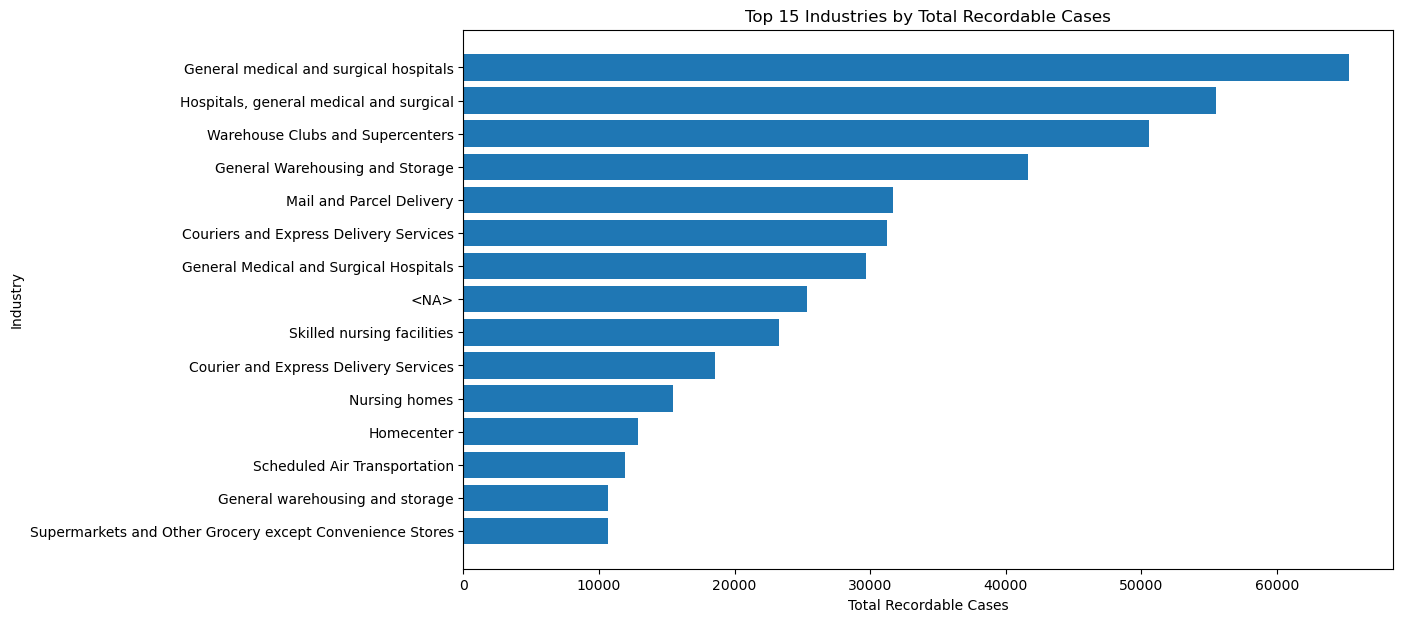

In [23]:
top_industries_cases = industry_summary.sort_values("total_recordable_cases", ascending=False).head(15)
plt.figure(figsize=(12, 7))
plt.barh(top_industries_cases["industry_description"].astype(str), top_industries_cases["total_recordable_cases"])
plt.gca().invert_yaxis()
plt.title("Top 15 Industries by Total Recordable Cases")
plt.xlabel("Total Recordable Cases")
plt.ylabel("Industry")
plt.show()

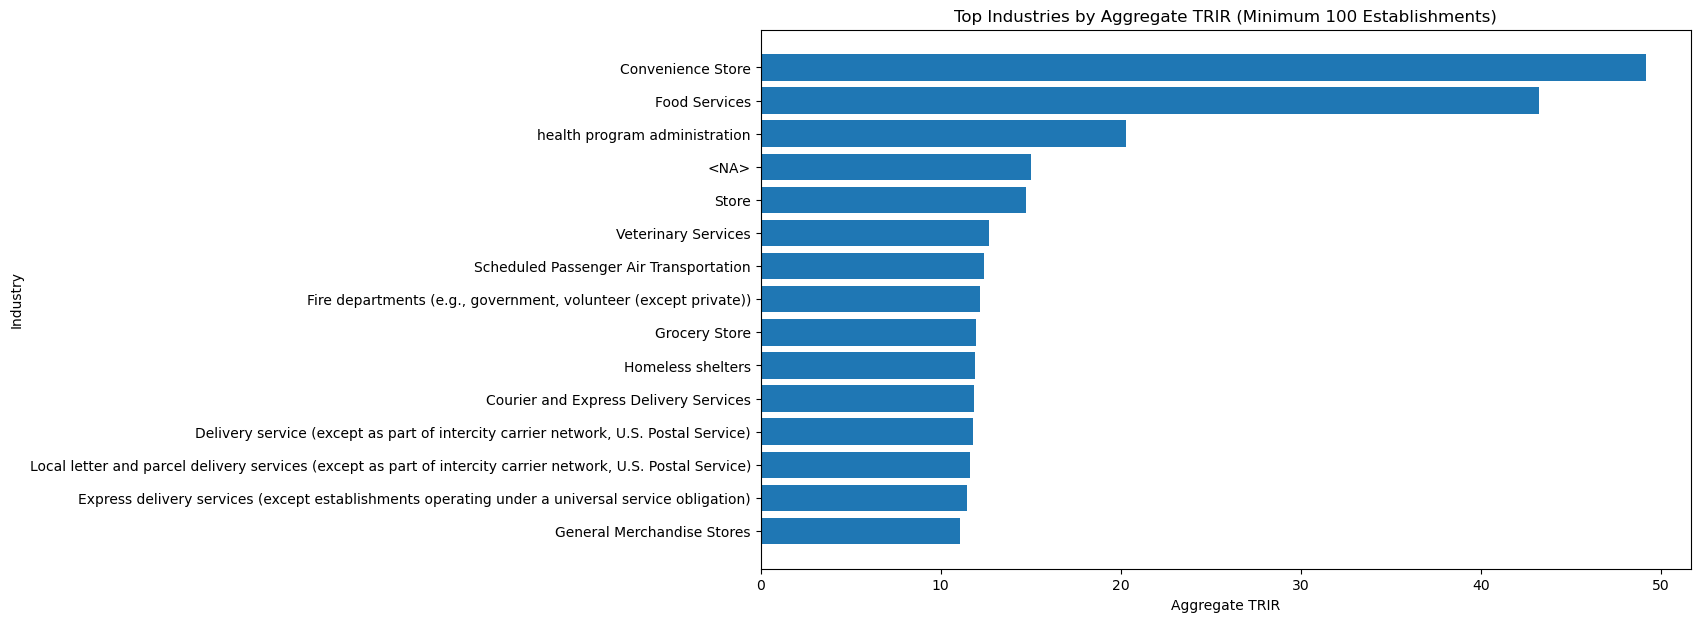

In [24]:
industry_rate_view = industry_summary[industry_summary["establishments"] >= 100].sort_values("industry_trir", ascending=False).head(15)
plt.figure(figsize=(12, 7))
plt.barh(industry_rate_view["industry_description"].astype(str), industry_rate_view["industry_trir"])
plt.gca().invert_yaxis()
plt.title("Top Industries by Aggregate TRIR (Minimum 100 Establishments)")
plt.xlabel("Aggregate TRIR")
plt.ylabel("Industry")
plt.show()

## 6. Candidate High-Risk Threshold Exploration

For modeling later, approach is to define high-risk establishments using the upper 25% or 10% of TRIR. This section compares possible thresholds. 

In [25]:
valid_trir = summary_eda_clean["trir"].replace([np.inf, -np.inf], np.nan).dropna()
thresholds = {
    "Top 25% TRIR": valid_trir.quantile(0.75),
    "Top 10% TRIR": valid_trir.quantile(0.90),
    "Top 5% TRIR": valid_trir.quantile(0.95)
}

threshold_table = []
for label, cutoff in thresholds.items():
    high_risk_count = (summary_eda_clean["trir"] >= cutoff).sum()
    threshold_table.append({
        "threshold_option": label,
        "trir_cutoff": cutoff,
        "high_risk_establishments": high_risk_count,
        "high_risk_pct": high_risk_count / len(summary_eda_clean) * 100
    })

threshold_df = pd.DataFrame(threshold_table)
threshold_df

,threshold_option,trir_cutoff,high_risk_establishments,high_risk_pct
0,Top 25% TRIR,5.516202,98229,25.000064
1,Top 10% TRIR,10.817243,39293,10.000382
2,Top 5% TRIR,15.766902,19646,5.000064


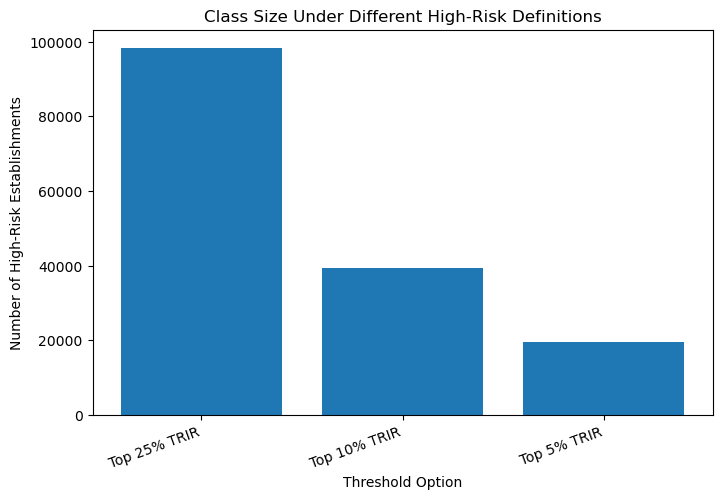

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(threshold_df["threshold_option"], threshold_df["high_risk_establishments"])
plt.title("Class Size Under Different High-Risk Definitions")
plt.xlabel("Threshold Option")
plt.ylabel("Number of High-Risk Establishments")
plt.xticks(rotation=20, ha="right")
plt.show()

In [27]:
trir_threshold = summary_eda_clean["trir"].quantile(0.75)

summary_eda_clean["high_risk"] = np.where(
    summary_eda_clean["trir"] >= trir_threshold,
    1,
    0
)

summary_eda_clean["high_risk"].value_counts(normalize=True)

high_risk
0    0.749999
1    0.250001
Name: proportion, dtype: float64

The high-risk target was defined using the top 25% of TRIR values. This threshold was selected because it identifies establishments with meaningfully elevated incident rates while maintaining enough positive cases for classification modeling. A stricter threshold, such as the top 10% or 5%, would identify only the most extreme cases but could create a more imbalanced modeling problem.

The target variable is intentionally imbalanced, with approximately 25% of establishments labeled as high-risk and 75% labeled as lower-risk. This reflects the real-world safety problem, where only a subset of establishments experience elevated incident rates. Because of this imbalance, later modeling will prioritize recall, F1-score, and class imbalance strategies rather than accuracy alone.


## 7. Case-Detail EDA

In [28]:
case_clean[[
    "incident_outcome", "dafw_num_away", "djtr_num_tr", "type_of_incident",
    "nature_title_pred", "part_title_pred", "event_title_pred", "source_title_pred"
]].head()

,incident_outcome,dafw_num_away,djtr_num_tr,type_of_incident,nature_title_pred,part_title_pred,event_title_pred,source_title_pred
0,4,0,0,1,Surface and flesh wounds,"Hand(s), finger(s)",Contact with non-running objects or equipment,Handtools
1,2,1,51,1,Surface and flesh wounds,Exterior and musculoskeletal structures of the...,"Slip, trip, stumble or fall on same level","Ground, travel, and support surfaces"
2,3,0,27,1,Soft tissue injuries,Multiple upper extremities locations,Overexertion while moving or manipulating exte...,Containers
3,3,0,14,1,Traumatic injuries or exposures-- nonspecific ...,"Hand(s), finger(s)",Contact with non-running objects or equipment,Building materials
4,3,0,5,1,Traumatic injuries or exposures-- nonspecific ...,"Hand(s), finger(s)",Contact with non-running objects or equipment,Building materials


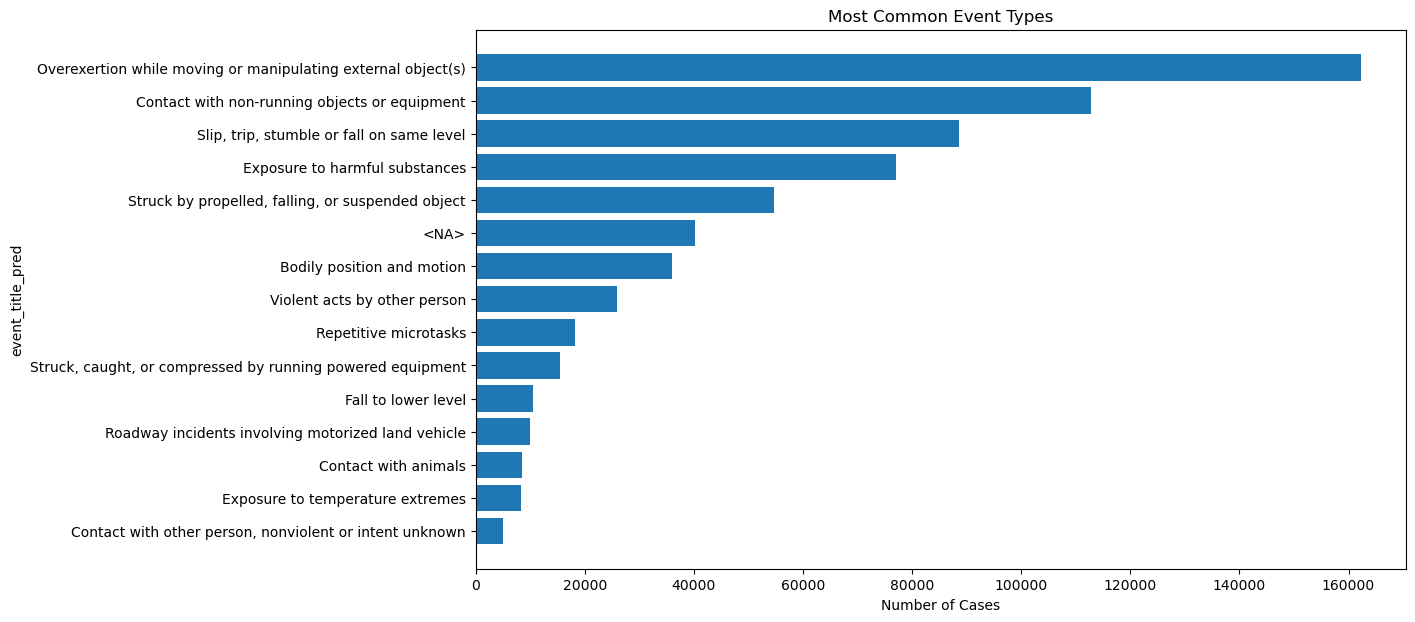

event_title_pred
Overexertion while moving or manipulating external object(s)    162352
Contact with non-running objects or equipment                   112726
Slip, trip, stumble or fall on same level                        88678
Exposure to harmful substances                                   76982
Struck by propelled, falling, or suspended object                54649
<NA>                                                             40206
Bodily position and motion                                       35975
Violent acts by other person                                     25867
Repetitive microtasks                                            18160
Struck, caught, or compressed by running powered equipment       15384
Fall to lower level                                              10576
Roadway incidents involving motorized land vehicle               10026
Contact with animals                                              8527
Exposure to temperature extremes                            

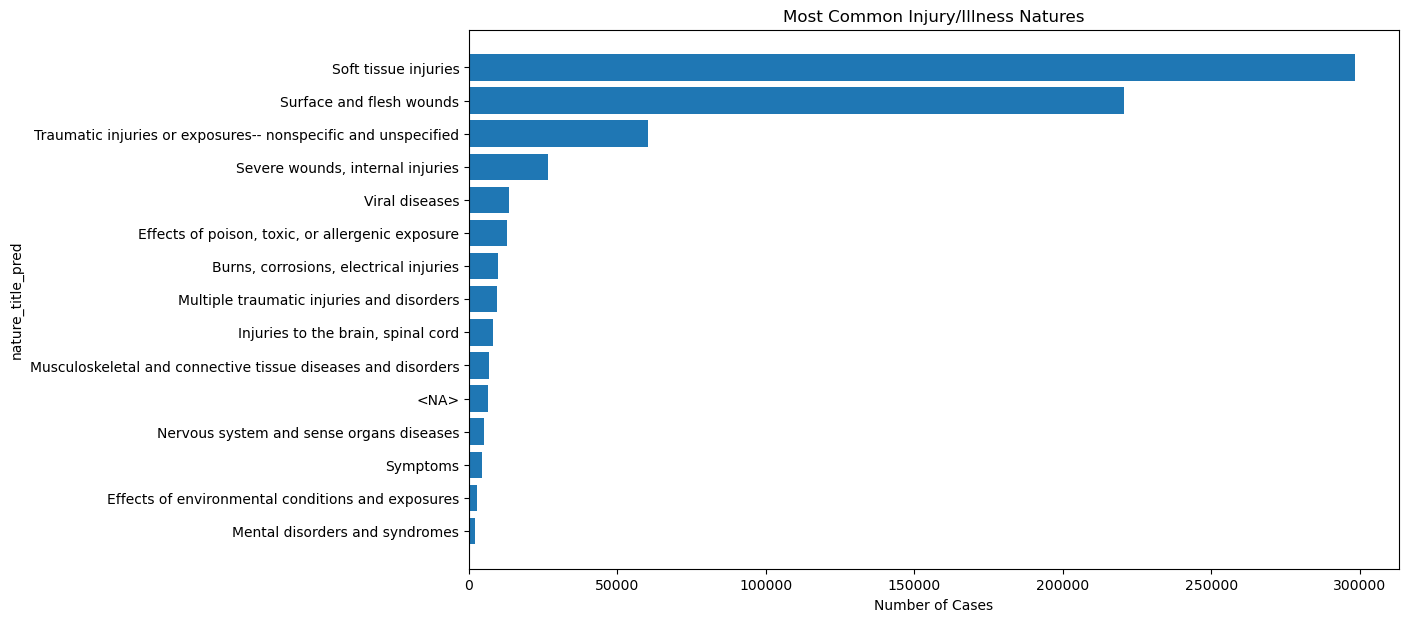

nature_title_pred
Soft tissue injuries                                             298320
Surface and flesh wounds                                         220568
Traumatic injuries or exposures-- nonspecific and unspecified     60293
Severe wounds, internal injuries                                  26441
Viral diseases                                                    13323
Effects of poison, toxic, or allergenic exposure                  12672
Burns, corrosions, electrical injuries                             9859
Multiple traumatic injuries and disorders                          9411
Injuries to the brain, spinal cord                                 8083
Musculoskeletal and connective tissue diseases and disorders       6864
<NA>                                                               6300
Nervous system and sense organs diseases                           4942
Symptoms                                                           4275
Effects of environmental conditions and exposu

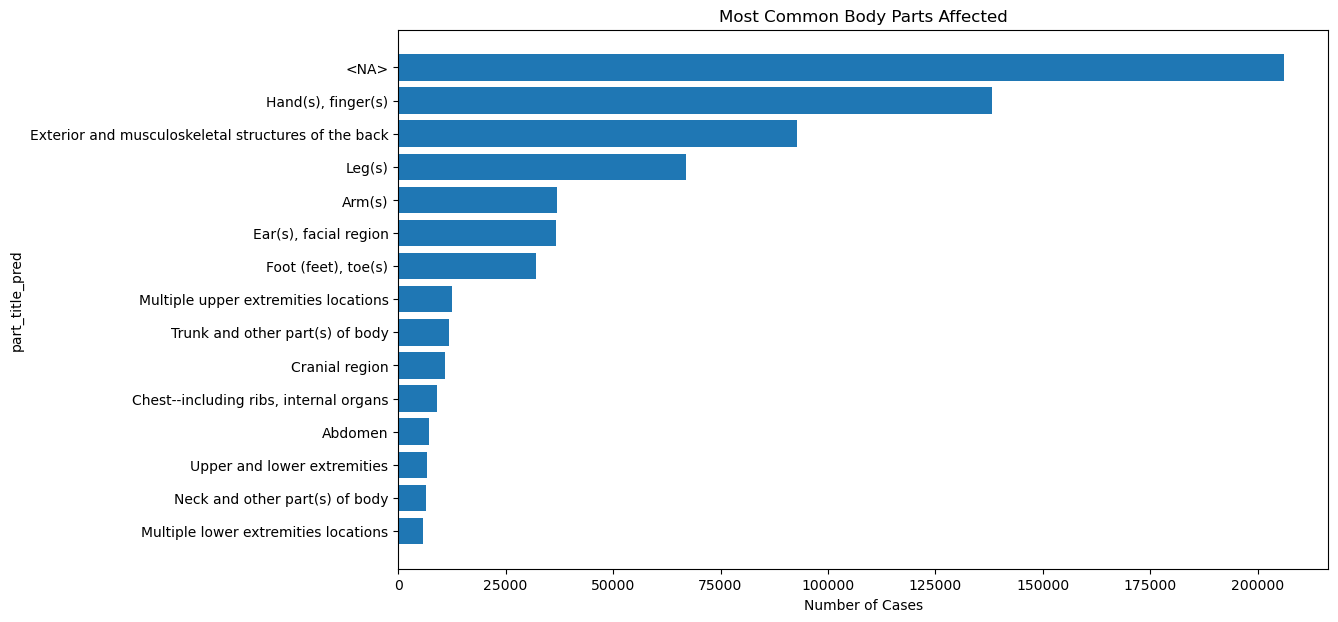

part_title_pred
<NA>                                                   206055
Hand(s), finger(s)                                     138083
Exterior and musculoskeletal structures of the back     92842
Leg(s)                                                  67074
Arm(s)                                                  36943
Ear(s), facial region                                   36758
Foot (feet), toe(s)                                     32065
Multiple upper extremities locations                    12476
Trunk and other part(s) of body                         11797
Cranial region                                          10896
Chest--including ribs, internal organs                   9040
Abdomen                                                  7105
Upper and lower extremities                              6665
Neck and other part(s) of body                           6395
Multiple lower extremities locations                     5829
Name: count, dtype: Int64

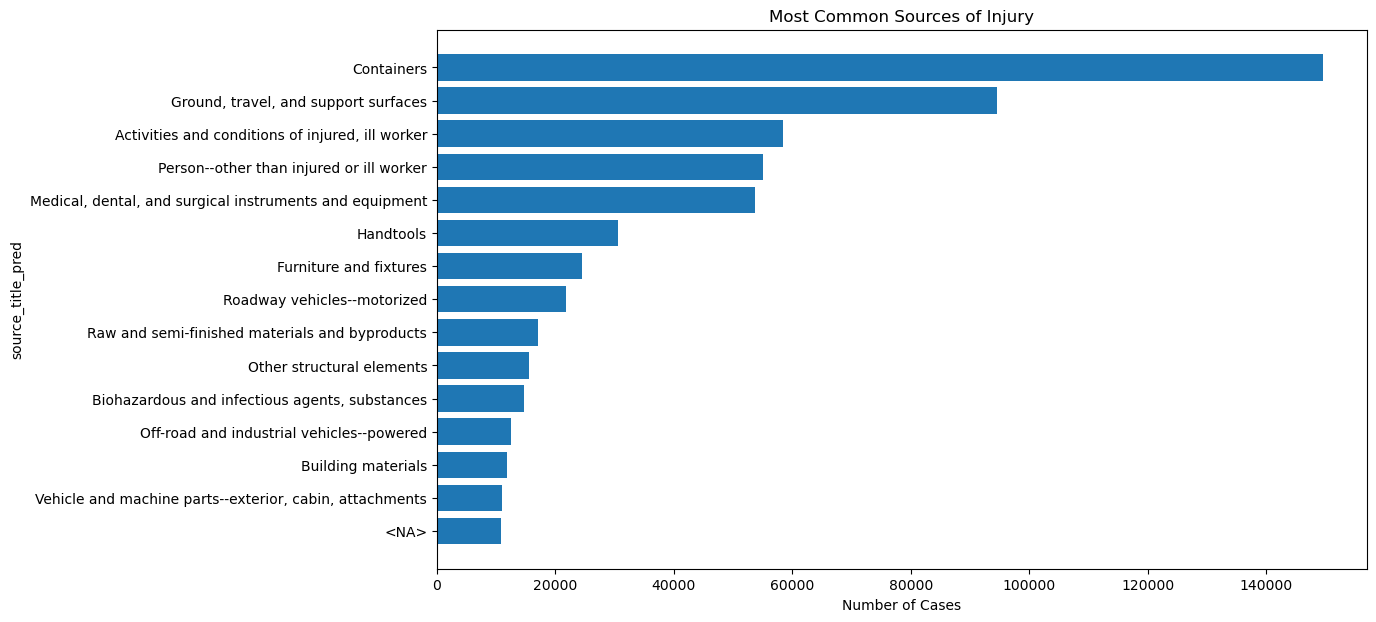

source_title_pred
Containers                                                 149546
Ground, travel, and support surfaces                        94572
Activities and conditions of injured, ill worker            58403
Person--other than injured or ill worker                    55126
Medical, dental, and surgical instruments and equipment     53778
Handtools                                                   30597
Furniture and fixtures                                      24449
Roadway vehicles--motorized                                 21742
Raw and semi-finished materials and byproducts              17065
Other structural elements                                   15565
Biohazardous and infectious agents, substances              14677
Off-road and industrial vehicles--powered                   12556
Building materials                                          11828
Vehicle and machine parts--exterior, cabin, attachments     10961
<NA>                                                      

In [29]:
def top_category_plot(df, column, title, top_n=15):
    counts = df[column].value_counts(dropna=False).head(top_n).sort_values()
    plt.figure(figsize=(12, 7))
    plt.barh(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel("Number of Cases")
    plt.ylabel(column)
    plt.show()
    return counts.sort_values(ascending=False)

for col, title in [
    ("event_title_pred", "Most Common Event Types"),
    ("nature_title_pred", "Most Common Injury/Illness Natures"),
    ("part_title_pred", "Most Common Body Parts Affected"),
    ("source_title_pred", "Most Common Sources of Injury")
]:
    if col in case_clean.columns:
        display(top_category_plot(case_clean, col, title))

In [30]:
# Days away / restricted distribution from case records
case_clean["total_case_days"] = case_clean.get("dafw_num_away", 0).fillna(0) + case_clean.get("djtr_num_tr", 0).fillna(0)

case_clean[["dafw_num_away", "djtr_num_tr", "total_case_days"]].describe().T

,count,mean,std,min,25%,50%,75%,max
dafw_num_away,688649.0,12.616837,86.271375,-9999.0,0.0,0.0,4.0,730.0
djtr_num_tr,688649.0,15.687487,225.784084,-99999.0,0.0,0.0,15.0,525.0
total_case_days,688649.0,28.304323,265.694321,-99999.0,0.0,7.0,34.0,780.0


## 8. Merge Feasibility and Case Aggregation

This checks whether the summary and case-detail datasets can be joined at the establishment level.

In [31]:
summary_ids = set(summary_eda["establishment_id"].dropna().astype(int))
case_ids = set(case_clean["establishment_id"].dropna().astype(int))

overlap_ids = summary_ids & case_ids

print(f"Summary establishments: {len(summary_ids):,}")
print(f"Case-detail establishments: {len(case_ids):,}")
print(f"Overlapping establishments: {len(overlap_ids):,}")
print(f"% of summary establishments with case detail: {len(overlap_ids) / len(summary_ids) * 100:.2f}%")
print(f"% of case-detail establishments in summary data: {len(overlap_ids) / len(case_ids) * 100:.2f}%")

Summary establishments: 398,620
Case-detail establishments: 64,674
Overlapping establishments: 64,674
% of summary establishments with case detail: 16.22%
% of case-detail establishments in summary data: 100.00%


In [32]:
case_agg = (case_clean
    .groupby("establishment_id")
    .agg(
        case_detail_count=("case_number", "count"),
        unique_event_types=("event_title_pred", "nunique"),
        unique_injury_natures=("nature_title_pred", "nunique"),
        case_days_total=("total_case_days", "sum"),
        case_days_median=("total_case_days", "median")
    )
    .reset_index())

case_agg.head()

,establishment_id,case_detail_count,unique_event_types,unique_injury_natures,case_days_total,case_days_median
0,41942,11,6,5,110,7.0
1,41952,0,1,1,0,0.0
2,41999,0,1,1,15,15.0
3,42012,0,1,1,0,0.0
4,42015,0,1,1,0,0.0


In [33]:
eda_merged = summary_eda.merge(case_agg, on="establishment_id", how="left")
eda_merged["has_case_detail"] = eda_merged["case_detail_count"].notna()

print("Merged shape:", eda_merged.shape)
display(eda_merged[["total_recordable_cases", "case_detail_count", "has_case_detail"]].describe().T)
display(eda_merged["has_case_detail"].value_counts(dropna=False))

Merged shape: (398620, 43)


,count,mean,std,min,25%,50%,75%,max
total_recordable_cases,398620.0,3.743856,18.135154,0.0,0.0,1.0,3.0,3054.0
case_detail_count,64674.0,6.907521,23.563064,0.0,0.0,2.0,7.0,1476.0


has_case_detail
False    333946
True      64674
Name: count, dtype: int64

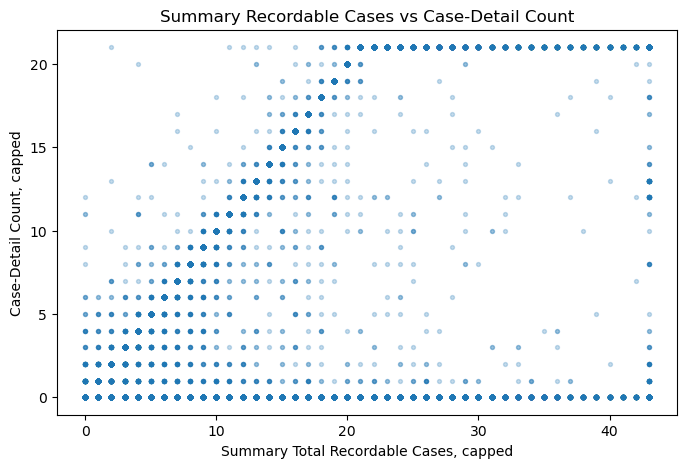

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(
    eda_merged["total_recordable_cases"].clip(upper=eda_merged["total_recordable_cases"].quantile(0.99)),
    eda_merged["case_detail_count"].fillna(0).clip(upper=eda_merged["case_detail_count"].fillna(0).quantile(0.99)),
    alpha=0.25,
    s=8
)
plt.title("Summary Recordable Cases vs Case-Detail Count")
plt.xlabel("Summary Total Recordable Cases, capped")
plt.ylabel("Case-Detail Count, capped")
plt.show()

## 9. Numeric Correlation Review

This is exploratory only. Correlation does not prove causation, and many safety variables are mechanically related.

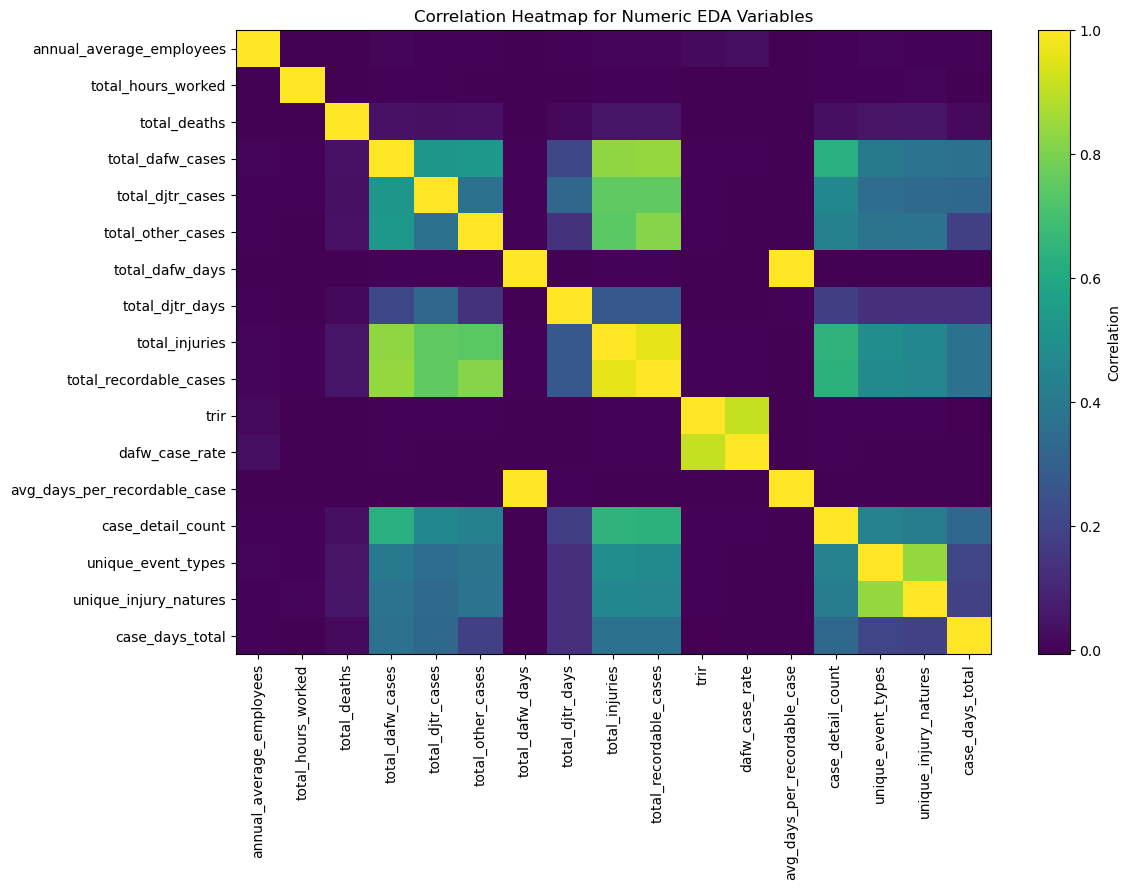

,annual_average_employees,total_hours_worked,total_deaths,total_dafw_cases,total_djtr_cases,total_other_cases,total_dafw_days,total_djtr_days,total_injuries,total_recordable_cases,trir,dafw_case_rate,avg_days_per_recordable_case,case_detail_count,unique_event_types,unique_injury_natures,case_days_total
annual_average_employees,1.000000e+00,-6.940041e-07,0.000144,0.006596,0.003830,0.004874,0.000014,0.001440,0.006430,0.006345,0.018936,0.030795,-0.000008,0.003147,0.006245,0.004785,0.001292
total_hours_worked,-6.940041e-07,1.000000e+00,-0.000048,0.002737,0.001305,0.000783,0.000001,0.000150,0.002177,0.001945,-0.000023,-0.000018,-0.000006,0.002427,0.004184,0.005406,0.000055
total_deaths,1.444480e-04,-4.790735e-05,1.000000,0.042508,0.037431,0.041126,0.000099,0.013181,0.048347,0.050187,0.000006,-0.000077,-0.000099,0.034622,0.047040,0.052828,0.017184
total_dafw_cases,6.596500e-03,2.737390e-03,0.042508,1.000000,0.525302,0.528108,0.003323,0.212152,0.834109,0.842312,0.003127,0.004176,-0.000264,0.633203,0.399775,0.375575,0.373796
total_djtr_cases,3.829539e-03,1.304593e-03,0.037431,0.525302,1.000000,0.367741,0.001586,0.326759,0.755408,0.753979,0.001397,0.000385,-0.000193,0.462870,0.351794,0.341847,0.328358
total_other_cases,4.873916e-03,7.828265e-04,0.041126,0.528108,0.367741,1.000000,0.001457,0.140820,0.742754,0.816981,0.002048,0.000462,-0.000486,0.434196,0.378597,0.375822,0.184677
total_dafw_days,1.445655e-05,1.115508e-06,0.000099,0.003323,0.001586,0.001457,1.000000,0.000617,0.002599,0.002600,-0.000010,-0.000005,0.999987,0.000741,-0.001410,-0.000800,0.000711
total_djtr_days,1.439750e-03,1.497427e-04,0.013181,0.212152,0.326759,0.140820,0.000617,1.000000,0.272360,0.272235,0.000519,0.000497,0.003086,0.180446,0.126931,0.127922,0.129721
total_injuries,6.430214e-03,2.177189e-03,0.048347,0.834109,0.755408,0.742754,0.002599,0.272360,1.000000,0.962405,0.002706,0.001925,-0.000412,0.646545,0.486425,0.464818,0.373237
total_recordable_cases,6.344503e-03,1.944961e-03,0.050187,0.842312,0.753979,0.816981,0.002600,0.272235,0.962405,1.000000,0.002729,0.002027,-0.000408,0.638756,0.472713,0.457430,0.368521


In [35]:
numeric_cols = [
    "annual_average_employees", "total_hours_worked", "total_deaths",
    "total_dafw_cases", "total_djtr_cases", "total_other_cases",
    "total_dafw_days", "total_djtr_days", "total_injuries",
    "total_recordable_cases", "trir", "dafw_case_rate",
    "avg_days_per_recordable_case", "case_detail_count",
    "unique_event_types", "unique_injury_natures", "case_days_total"
]

available_numeric = [col for col in numeric_cols if col in eda_merged.columns]
corr = eda_merged[available_numeric].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap for Numeric EDA Variables")
plt.tight_layout()
plt.show()

corr

## 10. Save EDA Outputs

These files will support presentation, Tableau dashboard, later modeling notebook.

In [36]:
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

summary_eda_clean.to_csv(OUTPUT_DIR / "summary_eda_clean_with_target.csv", index=False)
state_summary.to_csv(OUTPUT_DIR / "state_summary.csv", index=False)
industry_summary.to_csv(OUTPUT_DIR / "industry_summary.csv", index=False)
case_agg.to_csv(OUTPUT_DIR / "case_detail_aggregated_by_establishment.csv", index=False)
threshold_df.to_csv(OUTPUT_DIR / "candidate_high_risk_thresholds.csv", index=False)

print(f"Saved EDA outputs to: {OUTPUT_DIR.resolve()}")

Saved EDA outputs to: C:\Users\Ethan Moeller\Workplace Safety Project\eda_outputs


## 11. EDA Takeaways


1. **Data quality:** The summary dataset contains 398620 establishments and the case-detail dataset contains 688649  incident records. The most important missing fields are industry description and ein.
2. **Risk distribution:** TRIR is highly left-skewed, meaning most establishments have a lower to no number of incidents, leading to looking at industries separately.
3. **Industry pattern:** The industries with the highest total incident volume were medical and warehouse. The industries with the highest rate-based risk were convenience stores and food service.
4. **Geographic pattern:** The states with the highest total recordable cases were CA, FL and TX, as expected. ME has the highest TRIR by far.
5. **Incident drivers:** The most common event types were overexertion.
6. **Target definition:** Based on threshold exploration, I plan to define high-risk establishments as those in the top 25% of TRIR values because this identifies facilities with higher-than-normal incident rates while keeping enough data for effective model training.
7. **Modeling caution:** Fields used to define the target, such as total recordable cases and TRIR, should not be used as predictors in the modeling notebook.

## EDA Limitations

Several limitations should be considered. OSHA-reported data may contain reporting inconsistencies or underreporting. TRIR is useful for comparing establishments of different sizes, but it can be unstable for very small establishments with low hours worked. Extreme outliers were reviewed and filtered to reduce distortion in later analysis. Finally, incident history reflects reported past conditions and may not fully capture current workplace practices, safety culture, or recent operational changes.



In [ ]:
summary_eda_clean.to_csv(
    OUTPUT_DIR / "summary_eda_clean_with_target.csv",
    index=False
)

## Transition to Feature Engineering

The EDA confirms that workplace safety risk varies substantially across establishments, industries, and locations. The next step is to construct a model-ready dataset by engineering features that capture establishment characteristics, industry context, geographic patterns, and incident-type patterns while avoiding data leakage from variables used to define the target.